# Project Jaguationça: De quem são essas pintas? 🐾

## 🤖 Engineering Acknowledgments & Autonomy

This notebook was developed using an **AI Pair Programming** methodology. While I operated as the lead Data Engineer and Project Manager—defining data curation requirements, formatting camera trap constraints, and performing diagnostics—the code structure, MLOps pipeline optimizations, and interface layout were co-authored in collaboration with an advanced AI assistant.

## Jaguar vs Ocelot: The Conservation Context

The Jaguar (*Panthera onca*) and the Ocelot (*Leopardus pardalis*) are two distinct neotropical feline species native to the Americas. In Brazil, they share territories across various vital biomes, including the Pantanal, Cerrado, and the Atlantic Forest.

Because they coexist in the same habitats and are both wild cats characterized by yellow coats with black spots, they are frequently confused by those who are not familiar with each species' specific traits. In field conservation, this morphological similarity creates a significant data-triaging bottleneck when analyzing thousands of raw camera trap captures.




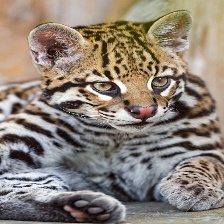 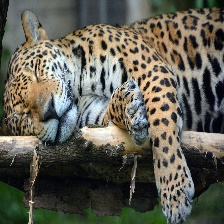

When automating wildlife monitoring with computer vision, understanding the morphological differences between target species is crucial for evaluating model behavior, especially under night-vision or infra-red conditions.

| Feature | Jaguar (*Panthera onca*) | Ocelot (*Leopardus pardalis*) |
| :--- | :--- | :--- |
| **Coat Pattern** | Large, open **rosettes** that contain one or more small **central black spots** inside them. | Elongated spots that connect into horizontal **chain-like bands** or stripes along the body. |
| **Body Size & Build** | Apex predator with a **massive, robust head**, thick neck, muscular chest, and powerful limbs. | Medium-sized wildcat with a **slender build**, narrower facial structure, and elongated body. |
| **Tail Proportions** | Relatively **short tail** that rarely touches the ground, used for balance while swimming or running. | Sleek, **long tail** that is significantly longer in proportion to its smaller body size. |
| **Biometrics** | Heavyweight feline ranging from **56 to 96 kg** (123 to 211 lbs) on average. | Lightweight feline ranging from **8 to 15 kg** (18 to 33 lbs) on average. |

---

## Project Objective

The primary objective of **Project Jaguationça** is to develop and deploy a high-precision computer vision model specialized in the automated identification and differentiation between these two sympatric felines.

Due to their overlapping physical traits, distinguishing between them poses a major challenge for automated monitoring systems—especially when processing low-resolution, obscured, or overexposed nighttime infrared (IR) imagery.

By leveraging Transfer Learning and specialized data engineering, this project built a classifier capable of analyzing and extracting subtle geometric pattern differences: the large, central-dotted rosettes unique to the Jaguar versus the elongated, chain-like horizontal stripes of the Ocelot. This provides wildlife researchers with an accurate, automated tool for species-specific population monitoring and smart conservation.

### 📦 1. Install Tools and Libraries

This section initializes the temporary virtual machine runtime envionment by installing all necessary software dependencies. We quietly fetch the core computer vision frameworks (`fastai` and `torch` for Deep Learning model architecture) and the interface engine (`gradio` for rendering the web application). This guarantees that the notebook remains fully reproducible and self-sufficient upon every fresh runtime execution.



In [9]:
# Install the core framework for Deep Learning (FastAI) and the Web Interface engine (Gradio)
!pip install -q fastai gradio

import os
import torch
import matplotlib.pyplot as plt
from fastai.vision.all import *

# Verify that the infrastructure is active and detect the core hardware configurations
print(f"Environment initialized successfully. PyTorch version: {torch.__version__}")


Environment initialized successfully. PyTorch version: 2.11.0+cu128


### 2. Model Architecture, Image Processing & Data Strategy

This block establishes the production-grade Deep Learning training pipeline. The architecture embraces a high-fidelity **Data-Centric AI** framework to ensure accurate feature extraction from both daytime and complex nighttime camera trap conditions.

---

#### 📂 Data Origin & Curation
The image repository deployed in this project was curated dynamically by harvesting, filtering, and incorporating specialized wildlife assets extracted directly from private **Google Photos** repositories, public ecological monitoring archives, and open-access Kaggle/Fastai community data collections to ensure realistic illumination diversity.

---

#### ⚙️ Core Components & Applied Strategies
*   **ResNet50 Architecture:** The system implements a deep **ResNet50** convolutional neural network utilizing pre-trained weights (*Transfer Learning*), leveraging its advanced structural *Bottleneck Layers* to accurately map subtle geometric variations and micro-textures within feline coat patterns.
*   **High-Resolution Tensor Processing:** Input arrays are explicitly standard-scaled to **448x448 pixels** (`Resize(448)`). This structural matrix configuration doubles the pixel density delivered to the initial convolutional filters, preserving pattern boundaries under harsh infrared flashes.
*   **Geometric Fidelity Constraints:** Real-time batch transformations (*Data Augmentation*) completely freeze artificial scaling factors (`max_zoom=1.0`), maintaining only slight rotations and horizontal flips. This forces the model to evaluate the pure physical continuity of ocelot stripes without scale distortions.
*   **Label Smoothing Regularization:** Integrates **Label Smoothing Cross Entropy** (`LabelSmoothingCrossEntropy`) directly into the loss function calculations. This mathematical constraint penalizes model overconfidence during backpropagation, effectively smoothing weights optimization and mitigating overfitting risks.



Data pipelines loaded with geometric augmentation layers. Target classes found: ['jaguar', 'ocelot']
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]



Executing deep learning training loop via Transfer Learning and Label Smoothing...


epoch,train_loss,valid_loss,error_rate,time
0,0.907631,0.521178,0.166667,00:16


epoch,train_loss,valid_loss,error_rate,time
0,0.635356,0.493610,0.120370,00:20
1,0.588087,0.390288,0.064815,00:20
2,0.565097,0.394294,0.055556,00:20
3,0.531713,0.398691,0.055556,00:20
4,0.483267,0.386868,0.055556,00:20



Generating final production performance metrics...


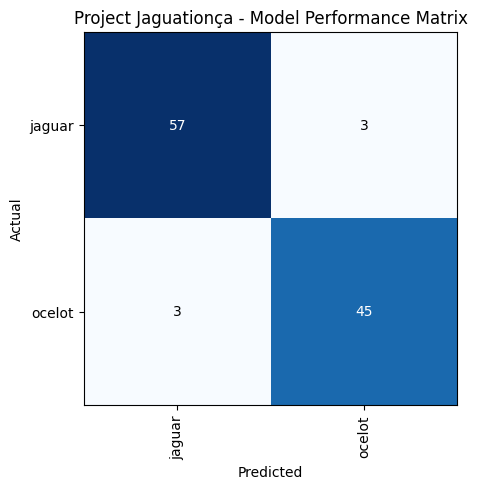


Detailed Classification Report:


              precision    recall  f1-score   support

      jaguar       0.95      0.95      0.95        60
      ocelot       0.94      0.94      0.94        48

    accuracy                           0.94       108
   macro avg       0.94      0.94      0.94       108
weighted avg       0.94      0.94      0.94       108


System model compiled and exported successfully as 'feline_classifier_model.pkl'!


In [13]:

# Establish the precise absolute path where the user manually uploaded the production folders
production_path = Path("/content/conservation_dataset")

# MLOps Security Check: Ensure the target data architecture exists before triggering weights optimization
if not os.path.exists(production_path):
    print("Engineering Error: The target directory 'conservation_dataset' was not found in the Colab sidebar.")
    print("Please make sure the upload pipeline has completed before running this block!")
else:
    # Create a streamlined DataBlock focused on real-world geometric robust training
    production_datablock = DataBlock(
        blocks=(ImageBlock, CategoryBlock), # Input: RGB Matrix | Output: Multiclass Categories
        get_items=get_image_files,          # Automatically query all standard image filenames within the path
        splitter=RandomSplitter(valid_pct=0.2, seed=42), # Isolate 20% of the dataset for unbiased model validation
        get_y=parent_label,                 # Extract target labels directly from the subfolder structural names
        item_tfms=Resize(448),               # Enforce uniform scale for ResNet tensor matrix operations
        batch_tfms=[
            # Geometric constraints: zoom set to 1.0 to preserve pure stripe continuity and rosette shapes
            *aug_transforms(do_flip=True, max_rotate=10.0, max_zoom=1.0)
        ]
    )

    # Load the structured data sequences into runtime GPU memory batches (batch size = 16)
    production_dls = production_datablock.dataloaders(production_path, bs=16)
    print("Data pipelines loaded with geometric augmentation layers. Target classes found:", production_dls.vocab)

    # Instantiate the ResNet34 convolutional architecture integrated with LabelSmoothingCrossEntropy
    production_learner = vision_learner(
        production_dls,
        resnet50,
        metrics=error_rate,
        loss_func=LabelSmoothingCrossEntropy()
    )

    # Fine-tune the deep pre-trained layers using an optimized learning rate sequence
    print("\nExecuting deep learning training loop via Transfer Learning and Label Smoothing...")
    production_learner.fine_tune(epochs=5, base_lr=1e-3)


    # Output evaluation visuals to demonstrate technical accuracy and performance metrics
    print("\nGenerating final production performance metrics...")
    interp_production = ClassificationInterpretation.from_learner(production_learner)
    interp_production.plot_confusion_matrix()
    plt.title("Project Jaguationça - Model Performance Matrix")
    plt.show()

    # Compute and print comprehensive precision, recall, and f1-score metrics distribution
    print("\nDetailed Classification Report:")
    interp_production.print_classification_report()

    # Serialize and export the optimized model weights for local execution or edge computing deployment
    production_learner.export('feline_classifier_model.pkl')
    print("\nSystem model compiled and exported successfully as 'feline_classifier_model.pkl'!")


### 🐾 Section 3: Production Inference Pipeline & Web Interface Application

This section instantiates the runtime inference engine and wraps the deep learning model within a highly accessible, production-ready web application powered by **Gradio**.

---

#### ⚙️ Inference & Interface Mechanics
*   **Model Deserialization:** The system dynamically loads the serialized binary weights (`feline_classifier_model.pkl`) compiled during the training loop back into the runtime memory.
*   **Real-Time Forward Propagation:** The application exposes a custom python wrapper (`classify_feline`) that ingests input images directly from the end-user, formats them to the target tensor grid, and executes forward propagation inference.
*   **Scientific Output Mapping:** Raw outputs are automatically transformed into distinct category predictions, mapping human-readable class strings to their calculated scientific float probabilities.
*   **Decoupled Deployment:** By executing `feline_interface.launch(share=True)`, the platform generates a local server wrapper alongside a secure public URL hosted on Gradio's live cloud infrastructure, making the system instantly interactable for field biologists and stakeholders.


In [15]:
import gradio as gr
from fastai.vision.all import load_learner

# Deserialize and load the compiled computer vision model weights from local disk memory
model_inference = load_learner('feline_classifier_model.pkl')

def classify_feline(input_image):
    """
    Process incoming images from the UI, feed them into the model,
    and return class probabilities.
    """
    if input_image is None:
        return {"Please submit an image": 1.0}

    # Execute forward propagation inference on the uploaded target asset
    predicted_class, class_idx, probabilities = model_inference.predict(input_image)

    # Map class strings to their calculated scientific float probabilities
    return {
        model_inference.dls.vocab[i]: float(probabilities[i])
        for i in range(len(model_inference.dls.vocab))
    }

# Build the minimalist Gradio interface wrapper for end-user interaction
feline_interface = gr.Interface(
    fn=classify_feline,
    inputs=gr.Image(type="pil", label="Wildlife Camera Trap Photo"),
    outputs=gr.Label(num_top_classes=2, label="Model Confidence Output"),
    title="Portal Jaguationça 🐾"
)

# Launch the secure server and output a shared public URL active for 72 consecutive hours
feline_interface.launch(share=True)


/usr/local/lib/python3.13/dist-packages/fastai/learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://436a37d95c3d316eed.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
